# Comparing Economic Performance Across China, the United States, and the United Kingdom Using Python

## 1. Introduction

Macroeconomic indicators can help us understand the overall performance of a country. This notebook compares the economic performance of China, the United States, and the United Kingdom using three indicators: GDP growth, inflation, and unemployment. The aim is to provide a simple and clear comparison that can help students better understand economic differences across countries.

## 2. Problem Statement and Target User

This project compares the economic performance of China, the United States, and the United Kingdom from 2014 to 2023.

The main research questions are:
1. Which country showed the strongest GDP growth in the selected period?
2. How did inflation differ across the three countries?
3. What can students learn from comparing these macroeconomic indicators?

The target users of this project are economics students, finance students, and general users who want to understand basic macroeconomic trends in a simple way.

## 3. Data Source and Access Date

The data used in this notebook were downloaded from the World Bank.

- Data source: World Bank
- Access date: 2026.04.22
- Selected countries: China, United States, United Kingdom
- Indicators used:
  - GDP growth (annual %)
  - Inflation, consumer prices (annual %)
  - Unemployment, total (% of total labor force) (modeled ILO estimate)
- Selected period: 2014 to 2023

## 4. Import Libraries

The following libraries are used for data handling, calculation, and visualisation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 5. Data Loading

This section imports the World Bank data file containing GDP growth, inflation, and unemployment indicators.

In [2]:
df = pd.read_csv("worldbank_data.csv")
df.head()

,Series Name,Series Code,Country Name,Country Code,2014 [YR2014],2015 [YR2015],2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023]
0,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,China,CHN,7.461900,6.978780,6.775556,6.891266,6.756718,6.068502,2.340188,8.570085,3.134189,5.414843
1,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,United States,USA,2.523820,2.945550,1.819451,2.457622,2.966505,2.583825,-2.163029,6.055053,2.512375,2.887556
2,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,United Kingdom,GBR,3.160174,2.140406,2.206520,3.023222,1.551331,1.256299,-10.047897,8.543112,5.149704,0.271650
3,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,China,CHN,1.921642,1.437024,2.000002,1.593136,2.074790,2.899234,2.419422,0.981015,1.973576,0.234837
4,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,United States,USA,1.622223,0.118627,1.261583,2.130110,2.442583,1.812210,1.233584,4.697859,8.002800,4.116338


## 6. Data Cleaning and Preparation

This section cleans and prepares the World Bank data for analysis. The data are reshaped into a format that is more suitable for country-year comparison and visualisation.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Series Name    11 non-null     object 
 1   Series Code    9 non-null      object 
 2   Country Name   9 non-null      object 
 3   Country Code   9 non-null      object 
 4   2014 [YR2014]  9 non-null      float64
 5   2015 [YR2015]  9 non-null      float64
 6   2016 [YR2016]  9 non-null      float64
 7   2017 [YR2017]  9 non-null      float64
 8   2018 [YR2018]  9 non-null      float64
 9   2019 [YR2019]  9 non-null      float64
 10  2020 [YR2020]  9 non-null      float64
 11  2021 [YR2021]  9 non-null      float64
 12  2022 [YR2022]  9 non-null      float64
 13  2023 [YR2023]  9 non-null      float64
dtypes: float64(10), object(4)
memory usage: 1.7+ KB


In [4]:
df.isnull().sum()

Series Name      3
Series Code      5
Country Name     5
Country Code     5
2014 [YR2014]    5
2015 [YR2015]    5
2016 [YR2016]    5
2017 [YR2017]    5
2018 [YR2018]    5
2019 [YR2019]    5
2020 [YR2020]    5
2021 [YR2021]    5
2022 [YR2022]    5
2023 [YR2023]    5
dtype: int64

In [5]:
year_cols = [col for col in df.columns if 'YR' in col]
id_cols = ['Series Name', 'Series Code', 'Country Name', 'Country Code']

df_long = df.melt(
    id_vars=id_cols,
    value_vars=year_cols,
    var_name='Year',
    value_name='Value'
)

df_long.head()

,Series Name,Series Code,Country Name,Country Code,Year,Value
0,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,China,CHN,2014 [YR2014],7.461900
1,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,United States,USA,2014 [YR2014],2.523820
2,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,United Kingdom,GBR,2014 [YR2014],3.160174
3,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,China,CHN,2014 [YR2014],1.921642
4,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,United States,USA,2014 [YR2014],1.622223


In [6]:
df_long['Year'] = df_long['Year'].str.extract(r'(\d{4})').astype(int)
df_long.head()

,Series Name,Series Code,Country Name,Country Code,Year,Value
0,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,China,CHN,2014,7.461900
1,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,United States,USA,2014,2.523820
2,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,United Kingdom,GBR,2014,3.160174
3,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,China,CHN,2014,1.921642
4,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,United States,USA,2014,1.622223


In [7]:
df_long['Value'] = pd.to_numeric(df_long['Value'], errors='coerce')
df_long = df_long.dropna(subset=['Value'])

df_long.info()

<class 'pandas.core.frame.DataFrame'>
Index: 90 entries, 0 to 134
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Series Name   90 non-null     object 
 1   Series Code   90 non-null     object 
 2   Country Name  90 non-null     object 
 3   Country Code  90 non-null     object 
 4   Year          90 non-null     int64  
 5   Value         90 non-null     float64
dtypes: float64(1), int64(1), object(4)
memory usage: 4.9+ KB


In [8]:
df_clean = df_long.pivot_table(
    index=['Country Name', 'Country Code', 'Year'],
    columns='Series Name',
    values='Value'
).reset_index()

df_clean.columns.name = None

df_clean = df_clean.rename(columns={
    'GDP growth (annual %)': 'GDP_growth',
    'Inflation, consumer prices (annual %)': 'Inflation',
    'Unemployment, total (% of total labor force) (modeled ILO estimate)': 'Unemployment'
})

df_clean.head()

,Country Name,Country Code,Year,GDP_growth,Inflation,Unemployment
0,China,CHN,2014,7.461900,1.921642,4.63
1,China,CHN,2015,6.978780,1.437024,4.65
2,China,CHN,2016,6.775556,2.000002,4.56
3,China,CHN,2017,6.891266,1.593136,4.47
4,China,CHN,2018,6.756718,2.074790,4.31


In [9]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country Name  30 non-null     object 
 1   Country Code  30 non-null     object 
 2   Year          30 non-null     int64  
 3   GDP_growth    30 non-null     float64
 4   Inflation     30 non-null     float64
 5   Unemployment  30 non-null     float64
dtypes: float64(3), int64(1), object(2)
memory usage: 1.5+ KB


The original World Bank dataset has been cleaned and reshaped into a format that is more suitable for analysis. Each row now represents one country in one year, with separate columns for GDP growth, inflation, and unemployment.

## 7. Exploratory Data Analysis

This section provides a simple overview of the cleaned data before the individual indicator analysis.

In [10]:
df_clean.groupby('Country Name')[['GDP_growth', 'Inflation', 'Unemployment']].mean()

,GDP_growth,Inflation,Unemployment
Country Name,,,
China,6.039203,1.753468,4.6380
United Kingdom,1.725452,2.764016,4.6291
United States,2.458873,2.743792,4.8929


The table above provides a first overview of the average GDP growth, inflation, and unemployment values for each country across the selected period.

## 8. GDP Growth Analysis

GDP growth is used to compare the pace of economic expansion across the selected countries.

In [11]:
df_clean.groupby("Country Name")["GDP_growth"].mean()

Country Name
China             6.039203
United Kingdom    1.725452
United States     2.458873
Name: GDP_growth, dtype: float64

China recorded the highest average GDP growth over the selected period.

## 9. Inflation Analysis

Inflation is used to compare changes in the general price level across the selected countries.

In [12]:
df_clean.groupby("Country Name")["Inflation"].mean()

Country Name
China             1.753468
United Kingdom    2.764016
United States     2.743792
Name: Inflation, dtype: float64

Average inflation was lower in China, while the United States and the United Kingdom showed higher inflation over the selected period.

## 10. Unemployment Analysis

Unemployment is used to compare labour market conditions across the selected countries.

In [13]:
df_clean.groupby("Country Name")["Unemployment"].mean()

Country Name
China             4.6380
United Kingdom    4.6291
United States     4.8929
Name: Unemployment, dtype: float64

Average unemployment differed across the three countries, suggesting different labour market conditions.

## 11. Visualisations

### 11.1 GDP Growth Comparison Across Three Countries

The following chart compares GDP growth across the three countries over time.

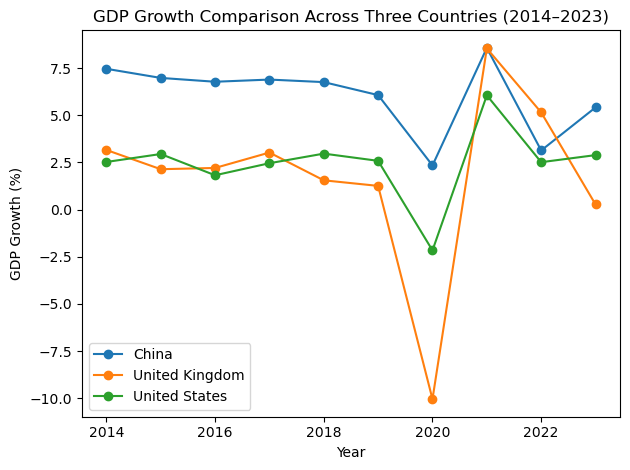

In [14]:
for country in df_clean['Country Name'].unique():
    temp = df_clean[df_clean['Country Name'] == country]
    plt.plot(temp['Year'], temp['GDP_growth'], marker='o', label=country)

plt.title('GDP Growth Comparison Across Three Countries (2014–2023)')
plt.xlabel('Year')
plt.ylabel('GDP Growth (%)')
plt.legend()
plt.tight_layout()
plt.show()

This chart shows how GDP growth changed over time in China, the United States, and the United Kingdom.

### 11.2 Inflation Comparison Across Three Countries

The following chart compares inflation across the three countries over time.

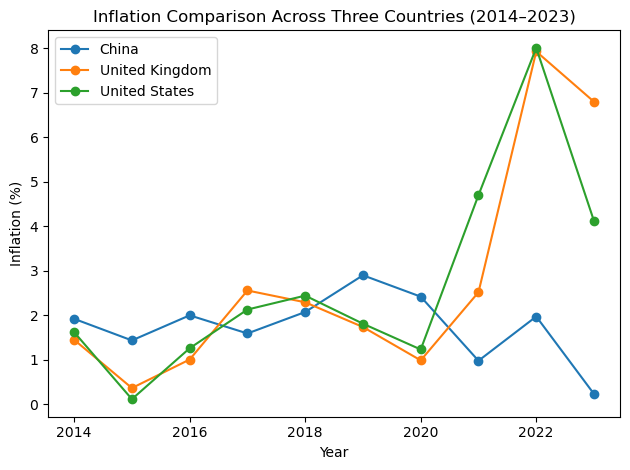

In [15]:
for country in df_clean['Country Name'].unique():
    temp = df_clean[df_clean['Country Name'] == country]
    plt.plot(temp['Year'], temp['Inflation'], marker='o', label=country)

plt.title('Inflation Comparison Across Three Countries (2014–2023)')
plt.xlabel('Year')
plt.ylabel('Inflation (%)')
plt.legend()
plt.tight_layout()
plt.show()

This chart shows how inflation differed across the three countries during the selected period.

### 11.3 Unemployment Comparison Across Three Countries

The following chart compares unemployment across the three countries over time.

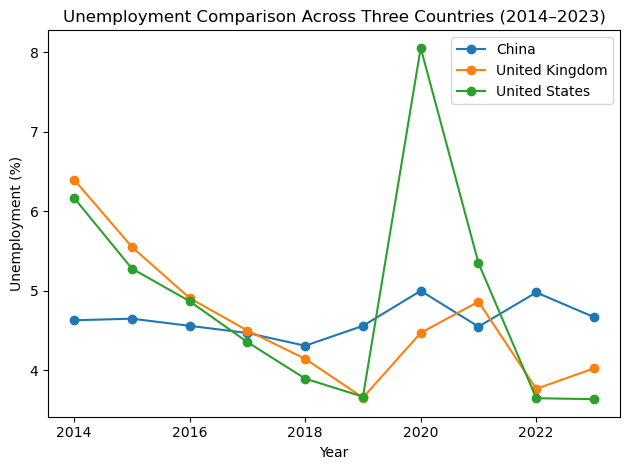

In [16]:
for country in df_clean['Country Name'].unique():
    temp = df_clean[df_clean['Country Name'] == country]
    plt.plot(temp['Year'], temp['Unemployment'], marker='o', label=country)

plt.title('Unemployment Comparison Across Three Countries (2014–2023)')
plt.xlabel('Year')
plt.ylabel('Unemployment (%)')
plt.legend()
plt.tight_layout()
plt.show()

This chart shows the differences in labour market conditions across the three countries.

## 12. Key Findings

1. China showed the strongest average GDP growth over the selected period.
2. Inflation was more volatile in the United States and the United Kingdom, especially after 2020.
3. Unemployment patterns differed across the three countries, indicating different labour market conditions.
4. Economic performance should be evaluated using multiple indicators rather than GDP growth alone.

## 13. Limitations

This project has several limitations. First, only three countries were selected, so the findings cannot represent the global economy as a whole. Second, only three macroeconomic indicators were used, which means that other important dimensions such as trade, public debt, exchange rates, and interest rates were not included. Third, the analysis is descriptive rather than causal, so it identifies patterns but does not fully explain the reasons behind them.

## 14. Conclusion

This notebook used World Bank data to compare economic performance across China, the United States, and the United Kingdom from 2014 to 2023. Using GDP growth, inflation, and unemployment together, the analysis showed clear differences across the three countries and demonstrated that economic performance should be interpreted through multiple indicators rather than a single measure.